In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import gridspec

In [2]:
def data_visualization(U, U_sim, OCV, I, t, SOC):
    plt.figure(figsize=(10, 8))

    #  Voltage
    plt.subplot(4, 1, 1)
    plt.plot(t, U, label='measured', linewidth=1.2)
    plt.plot(t, OCV, label='OCV', linewidth=1.2)
    plt.plot(t, U_sim, '--', label='simulated', linewidth=1.2)
    plt.ylabel('Voltage, V')
    plt.legend()
    plt.grid(True, alpha=0.3)

    #  Current
    plt.subplot(4, 1, 2)
    plt.plot(t, I, label='current', linewidth=1.2)
    plt.ylabel('Current, A')
    plt.title('Current')
    plt.grid(True, alpha=0.3)

    #  SOC
    plt.subplot(4, 1, 3)
    plt.plot(t, SOC, label='SOC', color='purple', linewidth=1.2)
    plt.ylabel('SOC')
    plt.title('State of Charge')
    plt.grid(True, alpha=0.3)

    # Error
    err = U - U_sim
    plt.subplot(4, 1, 4)
    plt.plot(t, err, label='error', linewidth=1.2)
    plt.ylabel('Error, V')
    plt.xlabel('Time, s')
    plt.title(f'Error (mean abs = {np.mean(np.abs(err)):.4f} V)')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()


In [3]:
current_dir = Path.cwd()

validation_results = current_dir.parent / "validation" / "validation_results.csv"

df_results = pd.read_csv(validation_results)

In [4]:
df_results

,profile,Battery_ID,SOH,T,SOC,Q_Ah,eta,OCV_file_name,R0,R,tau,UDDS_rmse,NEDC_rmse,WLTC_rmse
0,NEDC,1,94,25,55-35,3.289069,0.993163,OCV_1_+25.csv,0.040102,[ 0.18500965 -0.15799339],[74.79622419 74.46096847],0.001607,0.001041,0.003730
1,NEDC,1,94,25,75-55,3.289069,0.993163,OCV_1_+25.csv,0.043565,[ 2.38419122 -2.33588565],[76.6982802 75.91917751],0.003704,0.004663,0.009395
2,NEDC,1,94,25,95-75,3.289069,0.993163,OCV_1_+25.csv,0.044178,[-3.1062521 3.13802852],[76.12695194 76.00372429],0.005518,0.006065,0.006392
3,UDDS,1,94,25,55-35,3.289069,0.993163,OCV_1_+25.csv,0.038852,[ 0.05812656 -0.0271138 ],[70.43697862 64.5548939 ],0.001246,0.001514,0.002797
4,UDDS,1,94,25,75-55,3.289069,0.993163,OCV_1_+25.csv,0.040251,[ 0.14614713 -0.09671487],[70.3419654 63.7584806],0.003512,0.004939,0.010060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,impulse_288_s,5,98,35,75-55,3.434987,0.991690,OCV_5_+35.csv,0.041669,[ 0.11122546 -0.09116178],[63.50124231 51.079858 ],0.005389,0.006749,0.012505
266,impulse_288_s,5,98,35,95-75,3.434987,0.991690,OCV_5_+35.csv,0.037150,[ 0.04318691 -0.02255343],[60.161704 49.73728641],0.004207,0.005162,0.006004
267,impulse_72_s,5,98,35,55-35,3.434987,0.991690,OCV_5_+35.csv,0.037404,[ 0.0295919 -0.01634364],[23.43636714 5.62030503],0.004317,0.003572,0.006101
268,impulse_72_s,5,98,35,75-55,3.434987,0.991690,OCV_5_+35.csv,0.038704,[ 0.0609155 -0.0486512],[15.63131377 6.06766978],0.009007,0.010351,0.017256


In [5]:
# # Нужно построить таблицу из heatmap. Столбцы таблицы - SOC, строки - T. 
# В heatmap по оси x - profile, по оси y UDDS_rmse	NEDC_rmse	WLTC_rmse. Значения нужно усреднить по всем Battery_ID 

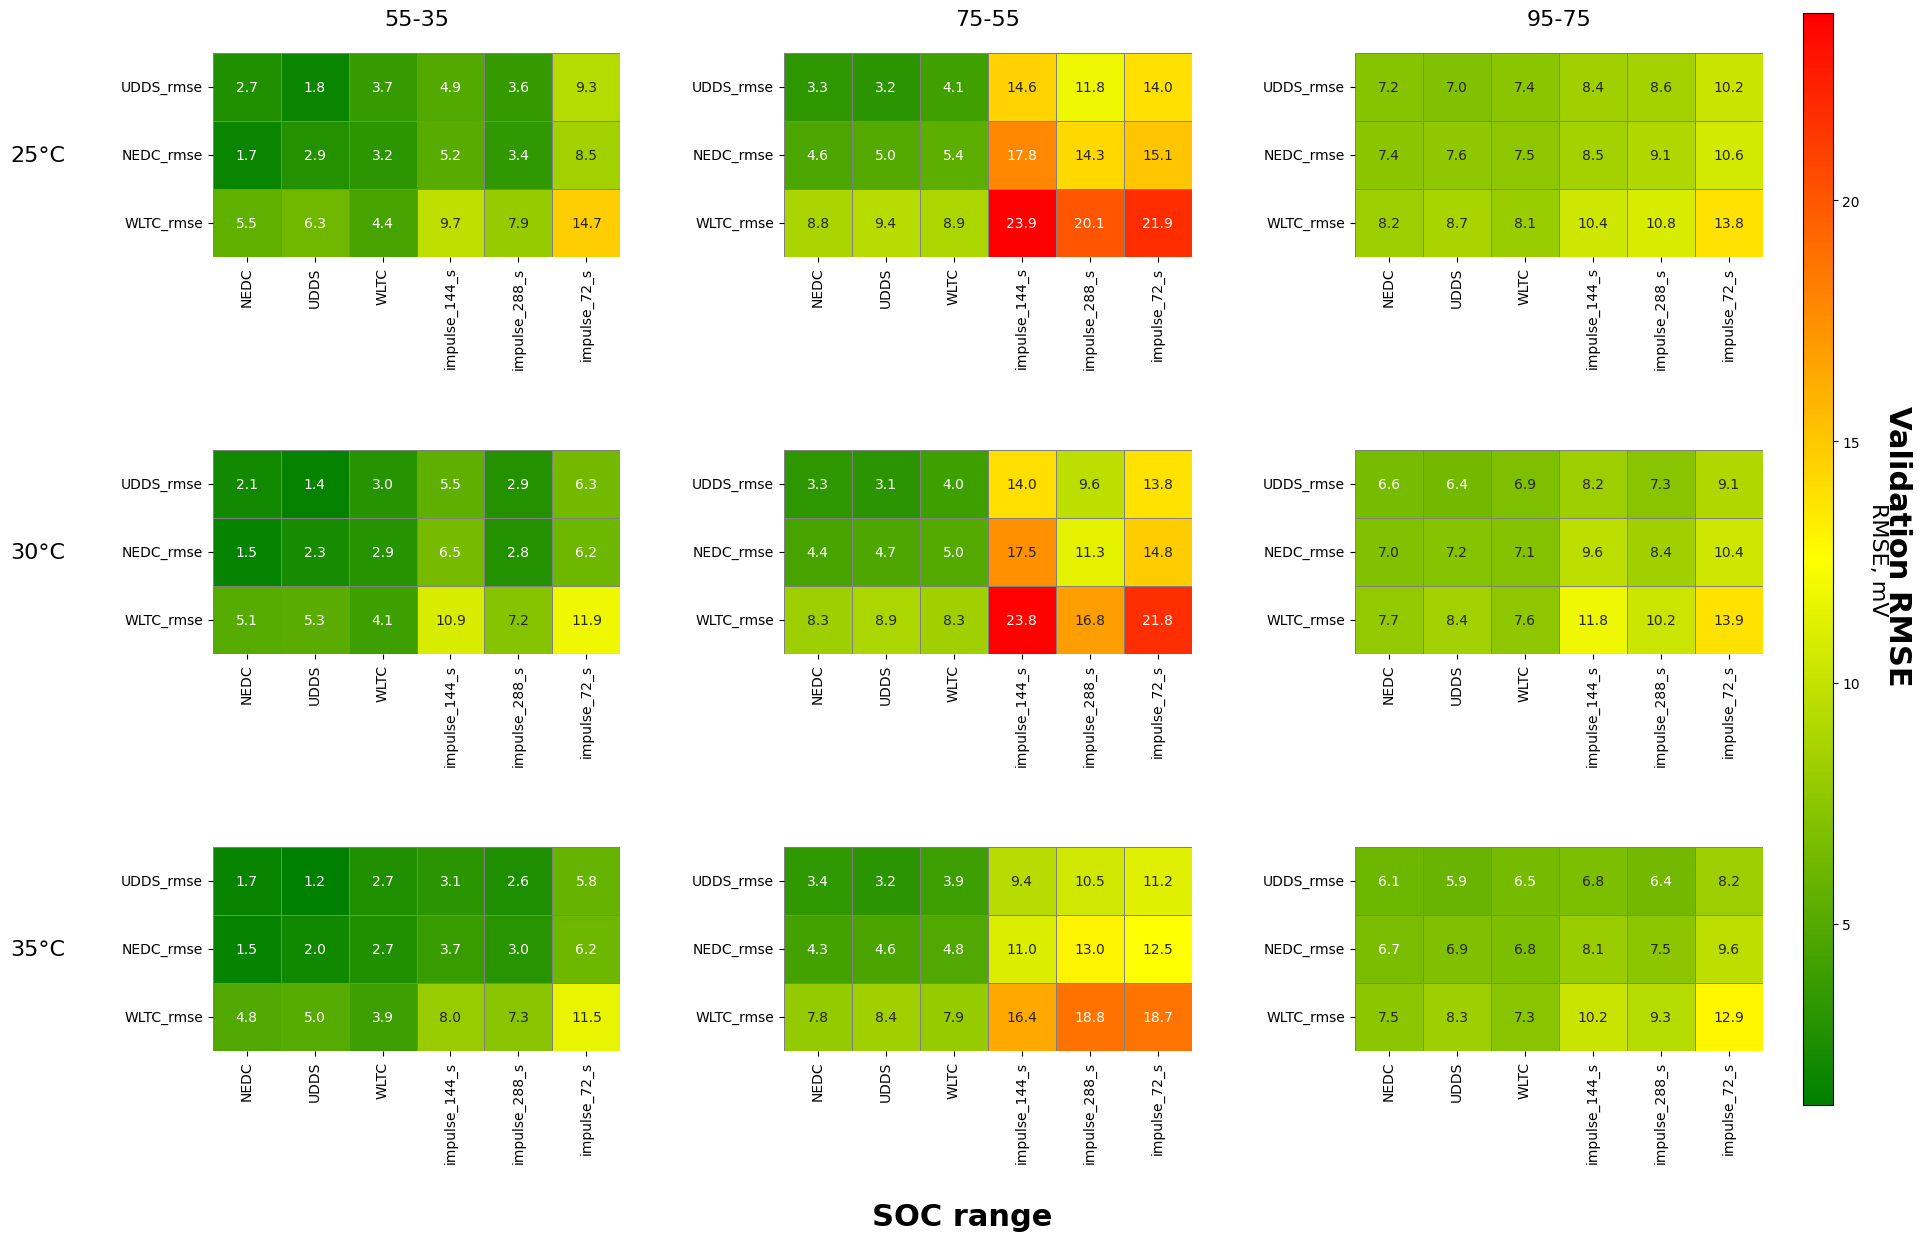

In [7]:
rmse_cols = ["UDDS_rmse", "NEDC_rmse", "WLTC_rmse"]

df_mean = (
    df_results
    .groupby(["SOC", "T", "profile"], as_index=False)[rmse_cols]
    .mean()
)



soc_ranges = sorted(df_mean["SOC"].unique())
temps = sorted(df_mean["T"].unique())

profiles = sorted(df_mean["profile"].unique())


validation_tables = {}

all_rmse = []

for soc in soc_ranges:
    validation_tables[soc] = {}
    for temp in temps:
        df_cell = df_mean[
            (df_mean["SOC"] == soc) &
            (df_mean["T"] == temp)
        ]

        if df_cell.empty:
            continue

        M = (
            df_cell
            .set_index("profile")[rmse_cols]
            .T
            .reindex(index=rmse_cols, columns=profiles)
        )

        validation_tables[soc][temp] = M
        all_rmse.extend(M.values.flatten())


vmin = min(all_rmse)
vmax = max(all_rmse)

vmin_scaled = vmin * 1000
vmax_scaled = vmax * 1000

cmap = LinearSegmentedColormap.from_list(
    "GYellowRed",
    ["green", "yellow", "red"]
)


fig = plt.figure(figsize=(20, 14))
gs = gridspec.GridSpec(
    len(temps),
    len(soc_ranges),
    figure=fig,
    wspace=0.4,
    hspace=0.4
)

for i, temp in enumerate(temps):
    for j, soc in enumerate(soc_ranges):
        ax = fig.add_subplot(gs[i, j])

        if temp not in validation_tables[soc]:
            ax.axis("off")
            continue

        M = validation_tables[soc][temp] * 1000  # → mV

        sns.heatmap(
            M,
            annot=True,
            fmt=".1f",
            cmap=cmap,
            vmin=vmin_scaled,
            vmax=vmax_scaled,
            cbar=False,
            ax=ax,
            square=True,
            linewidths=0.5,
            linecolor="gray"
        )

        ax.set_xlabel("")
        ax.set_ylabel("")


cbar_ax = fig.add_axes([0.92, 0.1, 0.015, 0.78])
sm = plt.cm.ScalarMappable(
    cmap=cmap,
    norm=plt.Normalize(vmin=vmin_scaled, vmax=vmax_scaled)
)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("RMSE, mV", fontsize=16, rotation=270, labelpad=20)


# Заголовки столбцов — SOC
for j, soc in enumerate(soc_ranges):
    fig.axes[j].set_title(
        soc.replace("_", "-"),
        fontsize=16,
        pad=20
    )

# Подписи строк — T
for i, temp in enumerate(temps):
    ax = fig.axes[i * len(soc_ranges)]
    ax.set_ylabel(
        f"{temp}°C",
        fontsize=16,
        rotation=0,
        labelpad=60,
        va="center"
    )


fig.text(
    0.5, 0.01,
    "SOC range",
    ha="center",
    va="bottom",
    fontsize=22,
    fontweight="bold"
)

fig.text(
    0.96, 0.5,
    "Validation RMSE",
    ha="left",
    va="center",
    rotation=270,
    fontsize=22,
    fontweight="bold"
)

plt.savefig(
    current_dir.parent / "validation" / "rmse_heatmap_SOC_T.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

